<a href="https://colab.research.google.com/github/Utsav-exe/HAR-Machine-Learning/blob/utsav%2Fpreprocessing/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Update this path based on what you named your files in Google Drive
dataset_path = '/content/drive/MyDrive/HAR_Data/train.csv'

# Load the data into a Pandas DataFrame
print("Loading dataset...")
df = pd.read_csv(dataset_path)

# Print the first 5 rows to see what you are working with
df.head()

Loading dataset...


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [5]:
# 1. Check for missing values (a crucial Day 1 EDA step)
print("Are there any missing values in the dataset?:", df.isnull().values.any())

# 2. Check the distribution of our target variable (the activities)
print("\n--- Activity Distribution ---")
# The Kaggle dataset usually has a column named 'Activity' at the very end
print(df['Activity'].value_counts())

# 3. Separate features (X) from labels (y)
# We drop 'Activity' because it's the answer key, and 'subject' because
# we don't want the model learning to identify a specific person.
X_train = df.drop(['Activity', 'subject'], axis=1)
y_train = df['Activity']

print(f"\nShape of X_train (features): {X_train.shape}")
print(f"Shape of y_train (labels): {y_train.shape}")

Are there any missing values in the dataset?: False

--- Activity Distribution ---
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Shape of X_train (features): (7352, 561)
Shape of y_train (labels): (7352,)


In [6]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the encoder
encoder = LabelEncoder()

# 2. Convert the text labels into numerical categories
y_train_encoded = encoder.fit_transform(y_train)

# 3. Create a dictionary to remember which number represents which activity
label_mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label Mapping dictionary:")
for activity, number in label_mapping.items():
    print(f"{activity}: {number}")

print(f"\nShape of encoded labels: {y_train_encoded.shape}")
print(f"First 10 encoded labels: {y_train_encoded[:10]}")

Label Mapping dictionary:
LAYING: 0
SITTING: 1
STANDING: 2
WALKING: 3
WALKING_DOWNSTAIRS: 4
WALKING_UPSTAIRS: 5

Shape of encoded labels: (7352,)
First 10 encoded labels: [2 2 2 2 2 2 2 2 2 2]


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

# 1. Split the data
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train, y_train_encoded, test_size=0.2, random_state=42
)

# 2. Convert Pandas DataFrames/Series to PyTorch Tensors
X_tensor = torch.tensor(X_train_split.values, dtype=torch.float32)
y_tensor = torch.tensor(y_train_split, dtype=torch.long)

# 3. Create a DataLoader (feeds data to the model in batches)
train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 4. Define the Deep Neural Network Architecture
class HAR_NeuralNet(nn.Module):
    def __init__(self):
        super(HAR_NeuralNet, self).__init__()
        self.layer1 = nn.Linear(561, 256)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.3)
        self.layer3 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

# 5. Initialize the model
pytorch_model = HAR_NeuralNet()
print("PyTorch Model Architecture successfully built!")

PyTorch Model Architecture successfully built!


In [10]:
import torch.nn as nn
import torch.optim as optim

# 1. Define how the model learns
criterion = nn.CrossEntropyLoss() # Standard for multi-class classification
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001) # The "learner"
epochs = 50 # How many times the model sees the whole dataset

print("Starting Neural Network Training...")

# 2. The Training Loop
for epoch in range(epochs):
    pytorch_model.train() # Put model in training mode
    running_loss = 0.0

    for inputs, labels in train_loader:
        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass (make predictions)
        outputs = pytorch_model(inputs)

        # Calculate the loss (how wrong the predictions were)
        loss = criterion(outputs, labels)

        # Backward pass (calculate adjustments)
        loss.backward()

        # Update weights (learn)
        optimizer.step()

        running_loss += loss.item()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {running_loss/len(train_loader):.4f}")

print("Training Complete!")

Starting Neural Network Training...
Epoch 10/50 - Loss: 0.0824
Epoch 20/50 - Loss: 0.0706
Epoch 30/50 - Loss: 0.0503
Epoch 40/50 - Loss: 0.0516
Epoch 50/50 - Loss: 0.0539
Training Complete!


Loading Final Exam (Test) Data...
Taking the exam...

Utsav's PyTorch Neural Network Accuracy: 93.11%



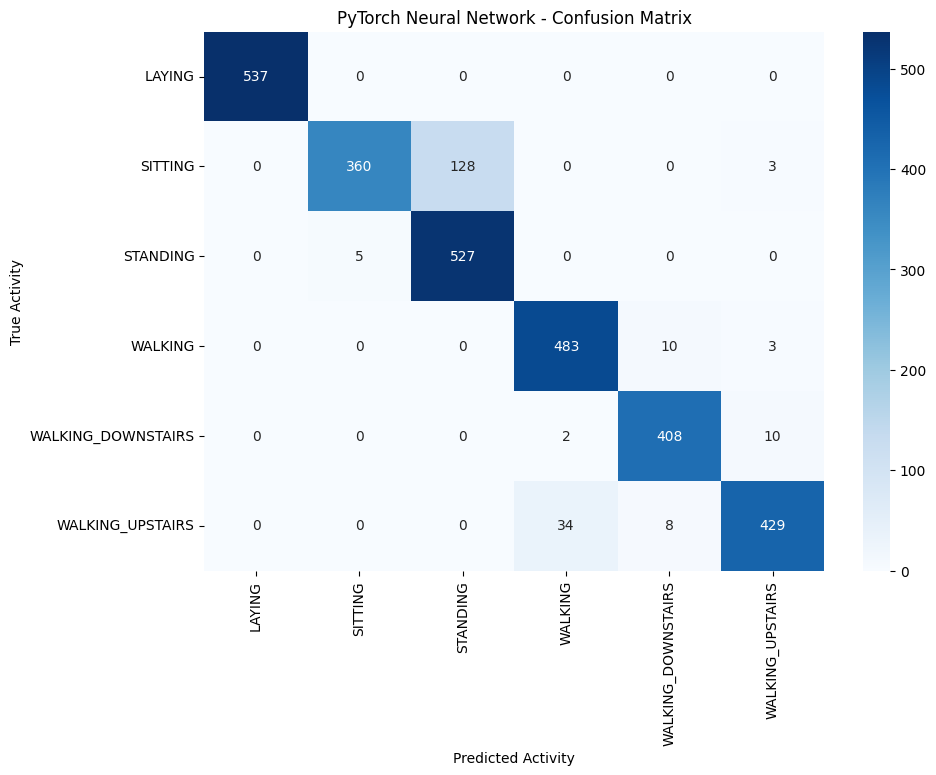

In [11]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

print("Loading Final Exam (Test) Data...")
# 1. Load the exact same Test Set your partner used
test_df = pd.read_csv('/content/drive/MyDrive/HAR_Data/test.csv')

# 2. Separate features and labels (just like Day 1)
X_test = test_df.drop(['Activity', 'subject'], axis=1)
# Use the Day 1 encoder to turn test labels into the same numbers!
y_test = encoder.transform(test_df['Activity'])

# 3. Convert Test Set to PyTorch Tensors
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

print("Taking the exam...")
# 4. Predict!
pytorch_model.eval() # Put model in test mode (turns off dropout)
with torch.no_grad(): # Don't update weights during testing, saves memory
    raw_predictions = pytorch_model(X_test_tensor)
    _, final_predictions = torch.max(raw_predictions, 1) # Get the highest probability guess

# 5. Calculate Utsav's High Score
nn_accuracy = accuracy_score(y_test, final_predictions.numpy())
print(f"\nUtsav's PyTorch Neural Network Accuracy: {nn_accuracy * 100:.2f}%\n")

# 6. Plot the Confusion Matrix
cm = confusion_matrix(y_test, final_predictions.numpy())
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('PyTorch Neural Network - Confusion Matrix')
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.show()